# RewardBench Survey Project Notebook
This notebook contains the experimental workflow for my survey project using the RewardBench framework.

The goal is to compare different reward-model approaches across the main RewardBench evaluation sections: Chat, Chat Hard, Safety, and Reasoning. The notebook evaluates both classifier-based reward models and DPO-style / implicit reward models.

The workflow includes setting up RewardBench, running the selected models with the official evaluation scripts, collecting section-level and subset-level scores, saving the processed results into CSV files, and generating figures for analysis.

The results from this notebook are used to compare model families, identify strengths and weaknesses across benchmark sections, and support the final ACL-style survey report.

#Contributors:
Rodela Ghosh

Divyansh Maurya


In [42]:
# Install RewardBench package
!pip install rewardbench

# Remove old clone if it exists
!rm -rf reward-bench

# Clone official RewardBench repository for scripts/run_rm.py and scripts/run_dpo.py
!git clone https://github.com/allenai/reward-bench.git

# Move into RewardBench repo
%cd reward-bench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 8.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 152.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Check GPU availability
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [5]:
# Create folders to save experiment logs
import os

os.makedirs("/content/rewardbench_results/raw_outputs", exist_ok=True)
os.makedirs("/content/rewardbench_results/figures", exist_ok=True)

print("Folders created.")

Folders created.


In [4]:
# Reduce unnecessary logging/noise
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

print("Environment variables set.")

Environment variables set.


In [3]:
# Patch RewardBench scripts so they do not upload results to Hugging Face
from pathlib import Path

for script_path in ["scripts/run_rm.py", "scripts/run_dpo.py"]:
    path = Path(script_path)
    text = path.read_text()

    patch = """
# Course project patch: disable Hugging Face Hub upload in Colab
def save_to_hub(*args, **kwargs):
    print("Skipping Hugging Face Hub upload; results kept locally.")
    return "local_only"

"""

    if "Course project patch: disable Hugging Face Hub upload" not in text:
        text = text.replace("\ndef main():", "\n" + patch + "\ndef main():")
        path.write_text(text)
        print(f"Patched {script_path}")
    else:
        print(f"Already patched {script_path}")

Patched scripts/run_rm.py
Patched scripts/run_dpo.py


In [7]:

# Run lightweight classifier-based reward model
!python scripts/run_rm.py \
  --model=OpenAssistant/reward-model-deberta-v3-large-v2 \
  --chat_template=raw \
  --batch_size=16 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/deberta_rm.log

2026-04-26 18:49:22.416924: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 18:49:22.435459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777229362.458216   13983 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777229362.465696   13983 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777229362.484880   13983 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
# Save completed DeBERTa results locally as CSV files

import pandas as pd
from pathlib import Path

# Create results folder
results_dir = Path("/content/rewardbench_results")
results_dir.mkdir(parents=True, exist_ok=True)

# Main model-level result
model_results = pd.DataFrame([
    {
        "model": "OpenAssistant/reward-model-deberta-v3-large-v2",
        "type": "Classifier RM",
        "overall": "",
        "chat": 0.8044692737430168,
        "chat_hard": 0.4407894736842105,
        "safety": 0.7662162162162162,
        "reasoning": 0.37757816336552624,
        "notes": "Completed local RewardBench run; HF upload disabled."
    }
])

# Long-format section scores
section_scores = pd.DataFrame([
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "section": "Chat", "score": 0.8044692737430168},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "section": "Chat Hard", "score": 0.4407894736842105},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "section": "Safety", "score": 0.7662162162162162},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "section": "Reasoning", "score": 0.37757816336552624},
])

# Detailed subset scores for deeper analysis
subset_scores = pd.DataFrame([
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "alpacaeval-easy", "score": 0.84},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "alpacaeval-hard", "score": 0.968421052631579},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "alpacaeval-length", "score": 0.6842105263157895},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "donotanswer", "score": 0.5147058823529411},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-cpp", "score": 0.5975609756097561},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-go", "score": 0.5853658536585366},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-java", "score": 0.823170731707317},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-js", "score": 0.4573170731707317},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-python", "score": 0.573170731707317},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "hep-rust", "score": 0.7560975609756098},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "llmbar-adver-GPTInst", "score": 0.7065217391304348},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "llmbar-adver-GPTOut", "score": 0.0},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "llmbar-adver-manual", "score": 0.3695652173913043},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "llmbar-adver-neighbor", "score": 0.4925373134328358},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "llmbar-natural", "score": 0.21},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "math-prm", "score": 0.12304250559284116},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "mt-bench-easy", "score": 0.5},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "mt-bench-hard", "score": 0.8648648648648649},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "mt-bench-med", "score": 0.825},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "refusals-dangerous", "score": 0.64},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "refusals-offensive", "score": 0.7},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "xstest-should-refuse", "score": 0.948051948051948},
    {"model": "OpenAssistant/reward-model-deberta-v3-large-v2", "subset": "xstest-should-respond", "score": 0.868},
])

# Save CSV files
model_results.to_csv(results_dir / "model_comparison.csv", index=False)
section_scores.to_csv(results_dir / "section_scores.csv", index=False)
subset_scores.to_csv(results_dir / "subset_scores.csv", index=False)

print("Saved:")
print(results_dir / "model_comparison.csv")
print(results_dir / "section_scores.csv")
print(results_dir / "subset_scores.csv")

Saved:
/content/rewardbench_results/model_comparison.csv
/content/rewardbench_results/section_scores.csv
/content/rewardbench_results/subset_scores.csv


In [7]:
# Display saved DeBERTa result
import pandas as pd

pd.read_csv("/content/rewardbench_results/model_comparison.csv")

,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...


In [4]:
# Run Qwen DPO with smallest batch size to avoid memory error
!python scripts/run_dpo.py \
  --model=Qwen/Qwen1.5-0.5B-Chat \
  --ref_model=Qwen/Qwen1.5-0.5B \
  --batch_size=1 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/qwen_05b_dpo_bs1.log

tee: /content/rewardbench_results/raw_outputs/qwen_05b_dpo_bs1.log: No such file or directory
2026-04-26 19:39:23.535233: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 19:39:23.553062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777232363.575656    3518 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777232363.583082    3518 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777232363.605346    3518 computation

In [8]:
# Append Qwen DPO results to local CSV files

import pandas as pd
from pathlib import Path

results_dir = Path("/content/rewardbench_results")

# Load existing CSVs
model_df = pd.read_csv(results_dir / "model_comparison.csv")
section_df = pd.read_csv(results_dir / "section_scores.csv")
subset_df = pd.read_csv(results_dir / "subset_scores.csv")

# Add Qwen model-level result
qwen_model = pd.DataFrame([
    {
        "model": "Qwen/Qwen1.5-0.5B-Chat",
        "type": "DPO-style",
        "overall": "",
        "chat": 0.3659217877094972,
        "chat_hard": 0.631578947368421,
        "safety": 0.5662162162162162,
        "reasoning": 0.606928984558302,
        "notes": "Completed local RewardBench DPO run with batch_size=1."
    }
])

# Add Qwen section scores
qwen_sections = pd.DataFrame([
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "section": "Chat", "score": 0.3659217877094972},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "section": "Chat Hard", "score": 0.631578947368421},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "section": "Safety", "score": 0.5662162162162162},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "section": "Reasoning", "score": 0.606928984558302},
])

# Add Qwen subset scores
qwen_subsets = pd.DataFrame([
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "alpacaeval-easy", "score": 0.06},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "alpacaeval-hard", "score": 0.3368421052631579},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "alpacaeval-length", "score": 0.6842105263157895},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "donotanswer", "score": 0.6029411764705882},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-cpp", "score": 0.49390243902439024},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-go", "score": 0.5121951219512195},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-java", "score": 0.4817073170731707},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-js", "score": 0.4878048780487805},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-python", "score": 0.4817073170731707},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "hep-rust", "score": 0.4634146341463415},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "llmbar-adver-GPTInst", "score": 0.6086956521739131},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "llmbar-adver-GPTOut", "score": 0.5106382978723404},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "llmbar-adver-manual", "score": 0.5869565217391305},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "llmbar-adver-neighbor", "score": 0.7686567164179104},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "llmbar-natural", "score": 0.56},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "math-prm", "score": 0.727069351230425},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "mt-bench-easy", "score": 0.39285714285714285},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "mt-bench-hard", "score": 0.5945945945945946},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "mt-bench-med", "score": 0.425},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "refusals-dangerous", "score": 0.81},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "refusals-offensive", "score": 0.83},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "xstest-should-refuse", "score": 0.8376623376623377},
    {"model": "Qwen/Qwen1.5-0.5B-Chat", "subset": "xstest-should-respond", "score": 0.176},
])

# Combine and save
model_df = pd.concat([model_df, qwen_model], ignore_index=True)
section_df = pd.concat([section_df, qwen_sections], ignore_index=True)
subset_df = pd.concat([subset_df, qwen_subsets], ignore_index=True)

model_df.to_csv(results_dir / "model_comparison.csv", index=False)
section_df.to_csv(results_dir / "section_scores.csv", index=False)
subset_df.to_csv(results_dir / "subset_scores.csv", index=False)

print("Qwen results saved.")
display(model_df)

Qwen results saved.


,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...
1,Qwen/Qwen1.5-0.5B-Chat,DPO-style,,0.365922,0.631579,0.566216,0.606929,Completed local RewardBench DPO run with batch...


In [20]:
# Patch run_rm.py so ArmoRM scores chosen/rejected separately
from pathlib import Path

path = Path("scripts/run_rm.py")
text = path.read_text()

old_block = '''            if model_type == "Custom Classifier":
                text_rejected = [b["text_rejected"] for b in batch]
                text_chosen = [b["text_chosen"] for b in batch]
                results_sub = reward_pipe(text_chosen, text_rejected, **reward_pipeline_kwargs)
                [results.append(1) if result else results.append(0) for result in results_sub.cpu().numpy().tolist()]
                scores_chosen.extend([None] * len(results_sub))
                scores_rejected.extend([None] * len(results_sub))
            else:
'''

new_block = '''            if model_type == "Custom Classifier" and reward_pipe.__class__.__name__ == "ArmoRMPipeline":
                # ArmoRM pipeline takes one list of text samples at a time
                rewards_chosen = reward_pipe(batch["text_chosen"], **reward_pipeline_kwargs)
                rewards_rejected = reward_pipe(batch["text_rejected"], **reward_pipeline_kwargs)

                # Convert logits to scores and compare chosen vs rejected
                score_chosen_batch = rewards_chosen.detach().float().view(-1).cpu().numpy().tolist()
                score_rejected_batch = rewards_rejected.detach().float().view(-1).cpu().numpy().tolist()

                for chosen_score, rejected_score in zip(score_chosen_batch, score_rejected_batch):
                    results.append(1 if chosen_score > rejected_score else 0)

                scores_chosen.extend(score_chosen_batch)
                scores_rejected.extend(score_rejected_batch)

            elif model_type == "Custom Classifier":
                # Legacy custom classifiers compare chosen/rejected directly
                text_rejected = [b["text_rejected"] for b in batch]
                text_chosen = [b["text_chosen"] for b in batch]
                results_sub = reward_pipe(text_chosen, text_rejected, **reward_pipeline_kwargs)
                [results.append(1) if result else results.append(0) for result in results_sub.cpu().numpy().tolist()]
                scores_chosen.extend([None] * len(results_sub))
                scores_rejected.extend([None] * len(results_sub))

            else:
'''

if old_block not in text:
    print("Original block not found. Patch may already be applied or file changed.")
else:
    text = text.replace(old_block, new_block)
    path.write_text(text)
    print("Patched ArmoRM handling in scripts/run_rm.py")

Patched ArmoRM handling in scripts/run_rm.py


In [21]:
# Recreate output folders
import os

os.makedirs("/content/rewardbench_results/raw_outputs", exist_ok=True)
os.makedirs("/content/rewardbench_results/figures", exist_ok=True)

print("Folders ready.")

Folders ready.


In [22]:
# Run ArmoRM after local patch
!python scripts/run_rm.py \
  --model=RLHFlow/ArmoRM-Llama3-8B-v0.1 \
  --batch_size=1 \
  --trust_remote_code \
  --do_not_save \
  2>&1 | tee /content/rewardbench_results/raw_outputs/armorm_patched_bs1.log

2026-04-26 20:18:07.737430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 20:18:07.755741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777234687.778662   13589 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777234687.786237   13589 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777234687.805504   13589 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [9]:
# Add ArmoRM results to local CSV files

import pandas as pd
from pathlib import Path

# Result folder
results_dir = Path("/content/rewardbench_results")
results_dir.mkdir(parents=True, exist_ok=True)

# Load existing result files
model_path = results_dir / "model_comparison.csv"
section_path = results_dir / "section_scores.csv"
subset_path = results_dir / "subset_scores.csv"

model_df = pd.read_csv(model_path)
section_df = pd.read_csv(section_path)
subset_df = pd.read_csv(subset_path)

# Remove old ArmoRM rows if this cell is run more than once
armorm_name = "RLHFlow/ArmoRM-Llama3-8B-v0.1"

model_df = model_df[model_df["model"] != armorm_name]
section_df = section_df[section_df["model"] != armorm_name]
subset_df = subset_df[subset_df["model"] != armorm_name]

# ArmoRM model-level result
armorm_model = pd.DataFrame([
    {
        "model": armorm_name,
        "type": "Custom Classifier RM",
        "overall": "",
        "chat": 0.9720670391061452,
        "chat_hard": 0.7631578947368421,
        "safety": 0.904054054054054,
        "reasoning": 0.9737784416434768,
        "notes": "Completed local RewardBench run after local ArmoRM pipeline patch; batch_size=1."
    }
])

# ArmoRM section scores
armorm_sections = pd.DataFrame([
    {"model": armorm_name, "section": "Chat", "score": 0.9720670391061452},
    {"model": armorm_name, "section": "Chat Hard", "score": 0.7631578947368421},
    {"model": armorm_name, "section": "Safety", "score": 0.904054054054054},
    {"model": armorm_name, "section": "Reasoning", "score": 0.9737784416434768},
])

# ArmoRM subset scores
armorm_subset_scores = {
    "alpacaeval-easy": 0.98,
    "alpacaeval-hard": 0.9368421052631579,
    "alpacaeval-length": 0.9789473684210527,
    "donotanswer": 0.7941176470588235,
    "hep-cpp": 0.9451219512195121,
    "hep-go": 0.9695121951219512,
    "hep-java": 0.975609756097561,
    "hep-js": 0.975609756097561,
    "hep-python": 0.9695121951219512,
    "hep-rust": 0.8902439024390244,
    "llmbar-adver-GPTInst": 0.7717391304347826,
    "llmbar-adver-GPTOut": 0.6595744680851063,
    "llmbar-adver-manual": 0.6739130434782609,
    "llmbar-adver-neighbor": 0.6865671641791045,
    "llmbar-natural": 0.93,
    "math-prm": 0.9932885906040269,
    "mt-bench-easy": 1.0,
    "mt-bench-hard": 0.8108108108108109,
    "mt-bench-med": 1.0,
    "refusals-dangerous": 0.93,
    "refusals-offensive": 0.97,
    "xstest-should-refuse": 0.9935064935064936,
    "xstest-should-respond": 0.872,
}

armorm_subsets = pd.DataFrame([
    {"model": armorm_name, "subset": subset, "score": score}
    for subset, score in armorm_subset_scores.items()
])

# Combine results
model_df = pd.concat([model_df, armorm_model], ignore_index=True)
section_df = pd.concat([section_df, armorm_sections], ignore_index=True)
subset_df = pd.concat([subset_df, armorm_subsets], ignore_index=True)

# Save updated CSV files
model_df.to_csv(model_path, index=False)
section_df.to_csv(section_path, index=False)
subset_df.to_csv(subset_path, index=False)

print("ArmoRM results added and saved.")
display(model_df)

ArmoRM results added and saved.


,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...
1,Qwen/Qwen1.5-0.5B-Chat,DPO-style,NaN,0.365922,0.631579,0.566216,0.606929,Completed local RewardBench DPO run with batch...
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,Custom Classifier RM,,0.972067,0.763158,0.904054,0.973778,Completed local RewardBench run after local Ar...


In [27]:
# Run stronger DPO-style model with reference model
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python scripts/run_dpo.py \
  --model=HuggingFaceH4/zephyr-7b-beta \
  --ref_model=mistralai/Mistral-7B-v0.1 \
  --batch_size=1 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/zephyr_7b_beta_dpo_bs1.log

2026-04-26 20:38:55.200045: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 20:38:55.218676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777235935.241175   18962 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777235935.248731   18962 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777235935.267807   18962 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [10]:
# Add Zephyr DPO results to local CSV files

import pandas as pd
from pathlib import Path

# Result folder
results_dir = Path("/content/rewardbench_results")
results_dir.mkdir(parents=True, exist_ok=True)

# File paths
model_path = results_dir / "model_comparison.csv"
section_path = results_dir / "section_scores.csv"
subset_path = results_dir / "subset_scores.csv"

# Load existing results
model_df = pd.read_csv(model_path)
section_df = pd.read_csv(section_path)
subset_df = pd.read_csv(subset_path)

# Remove old Zephyr rows if rerunning this cell
zephyr_name = "HuggingFaceH4/zephyr-7b-beta"

model_df = model_df[model_df["model"] != zephyr_name]
section_df = section_df[section_df["model"] != zephyr_name]
subset_df = subset_df[subset_df["model"] != zephyr_name]

# Zephyr model-level result
zephyr_model = pd.DataFrame([
    {
        "model": zephyr_name,
        "type": "DPO-style",
        "overall": "",
        "chat": 0.9245810055865922,
        "chat_hard": 0.6600877192982456,
        "safety": 0.6297297297297297,
        "reasoning": 0.7611584001746057,
        "notes": "Completed local RewardBench DPO run with batch_size=1."
    }
])

# Zephyr section scores
zephyr_sections = pd.DataFrame([
    {"model": zephyr_name, "section": "Chat", "score": 0.9245810055865922},
    {"model": zephyr_name, "section": "Chat Hard", "score": 0.6600877192982456},
    {"model": zephyr_name, "section": "Safety", "score": 0.6297297297297297},
    {"model": zephyr_name, "section": "Reasoning", "score": 0.7611584001746057},
])

# Zephyr subset scores
zephyr_subset_scores = {
    "alpacaeval-easy": 0.85,
    "alpacaeval-hard": 0.9789473684210527,
    "alpacaeval-length": 0.9368421052631579,
    "donotanswer": 0.6544117647058824,
    "hep-cpp": 0.9024390243902439,
    "hep-go": 0.9451219512195121,
    "hep-java": 0.9390243902439024,
    "hep-js": 0.9390243902439024,
    "hep-python": 0.9085365853658537,
    "hep-rust": 0.9024390243902439,
    "llmbar-adver-GPTInst": 0.40217391304347827,
    "llmbar-adver-GPTOut": 0.5957446808510638,
    "llmbar-adver-manual": 0.6956521739130435,
    "llmbar-adver-neighbor": 0.7089552238805971,
    "llmbar-natural": 0.8,
    "math-prm": 0.5995525727069351,
    "mt-bench-easy": 0.8928571428571429,
    "mt-bench-hard": 0.7837837837837838,
    "mt-bench-med": 0.975,
    "refusals-dangerous": 0.32,
    "refusals-offensive": 0.15,
    "xstest-should-refuse": 0.5584415584415584,
    "xstest-should-respond": 0.976,
}

zephyr_subsets = pd.DataFrame([
    {"model": zephyr_name, "subset": subset, "score": score}
    for subset, score in zephyr_subset_scores.items()
])

# Combine
model_df = pd.concat([model_df, zephyr_model], ignore_index=True)
section_df = pd.concat([section_df, zephyr_sections], ignore_index=True)
subset_df = pd.concat([subset_df, zephyr_subsets], ignore_index=True)

# Save
model_df.to_csv(model_path, index=False)
section_df.to_csv(section_path, index=False)
subset_df.to_csv(subset_path, index=False)

print("Zephyr results added and saved.")

print("\nModel comparison:")
display(model_df)

print("\nSection scores:")
display(section_df)

Zephyr results added and saved.

Model comparison:


,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...
1,Qwen/Qwen1.5-0.5B-Chat,DPO-style,NaN,0.365922,0.631579,0.566216,0.606929,Completed local RewardBench DPO run with batch...
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,Custom Classifier RM,NaN,0.972067,0.763158,0.904054,0.973778,Completed local RewardBench run after local Ar...
3,HuggingFaceH4/zephyr-7b-beta,DPO-style,,0.924581,0.660088,0.629730,0.761158,Completed local RewardBench DPO run with batch...



Section scores:


,model,section,score
0,OpenAssistant/reward-model-deberta-v3-large-v2,Chat,0.804469
1,OpenAssistant/reward-model-deberta-v3-large-v2,Chat Hard,0.440789
2,OpenAssistant/reward-model-deberta-v3-large-v2,Safety,0.766216
3,OpenAssistant/reward-model-deberta-v3-large-v2,Reasoning,0.377578
4,Qwen/Qwen1.5-0.5B-Chat,Chat,0.365922
5,Qwen/Qwen1.5-0.5B-Chat,Chat Hard,0.631579
6,Qwen/Qwen1.5-0.5B-Chat,Safety,0.566216
7,Qwen/Qwen1.5-0.5B-Chat,Reasoning,0.606929
8,RLHFlow/ArmoRM-Llama3-8B-v0.1,Chat,0.972067
9,RLHFlow/ArmoRM-Llama3-8B-v0.1,Chat Hard,0.763158


In [11]:
# Final verification: show saved CSV files and preview final tables

import pandas as pd
from pathlib import Path

# Result folder
results_dir = Path("/content/rewardbench_results")

# File paths
model_path = results_dir / "model_comparison.csv"
section_path = results_dir / "section_scores.csv"
subset_path = results_dir / "subset_scores.csv"

# Show saved files
print("Saved result files:")
!ls -lh /content/rewardbench_results

# Load CSV files
model_df = pd.read_csv(model_path)
section_df = pd.read_csv(section_path)
subset_df = pd.read_csv(subset_path)

# Preview final tables
print("\nFinal model comparison table:")
display(model_df)

print("\nFinal section scores table:")
display(section_df)

print("\nSubset scores preview:")
display(subset_df.head(20))

# Quick sanity check
print("\nNumber of models in model_comparison.csv:", model_df["model"].nunique())
print("Number of rows in section_scores.csv:", len(section_df))
print("Number of rows in subset_scores.csv:", len(subset_df))

Saved result files:
total 24K
drwxr-xr-x 2 root root 4.0K Apr 26 22:16 figures
-rw-r--r-- 1 root root  790 Apr 26 22:20 model_comparison.csv
drwxr-xr-x 2 root root 4.0K Apr 26 22:20 raw_outputs
-rw-r--r-- 1 root root  965 Apr 26 22:20 section_scores.csv
-rw-r--r-- 1 root root 5.6K Apr 26 22:20 subset_scores.csv

Final model comparison table:


,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...
1,Qwen/Qwen1.5-0.5B-Chat,DPO-style,NaN,0.365922,0.631579,0.566216,0.606929,Completed local RewardBench DPO run with batch...
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,Custom Classifier RM,NaN,0.972067,0.763158,0.904054,0.973778,Completed local RewardBench run after local Ar...
3,HuggingFaceH4/zephyr-7b-beta,DPO-style,NaN,0.924581,0.660088,0.629730,0.761158,Completed local RewardBench DPO run with batch...



Final section scores table:


,model,section,score
0,OpenAssistant/reward-model-deberta-v3-large-v2,Chat,0.804469
1,OpenAssistant/reward-model-deberta-v3-large-v2,Chat Hard,0.440789
2,OpenAssistant/reward-model-deberta-v3-large-v2,Safety,0.766216
3,OpenAssistant/reward-model-deberta-v3-large-v2,Reasoning,0.377578
4,Qwen/Qwen1.5-0.5B-Chat,Chat,0.365922
5,Qwen/Qwen1.5-0.5B-Chat,Chat Hard,0.631579
6,Qwen/Qwen1.5-0.5B-Chat,Safety,0.566216
7,Qwen/Qwen1.5-0.5B-Chat,Reasoning,0.606929
8,RLHFlow/ArmoRM-Llama3-8B-v0.1,Chat,0.972067
9,RLHFlow/ArmoRM-Llama3-8B-v0.1,Chat Hard,0.763158



Subset scores preview:


,model,subset,score
0,OpenAssistant/reward-model-deberta-v3-large-v2,alpacaeval-easy,0.840000
1,OpenAssistant/reward-model-deberta-v3-large-v2,alpacaeval-hard,0.968421
2,OpenAssistant/reward-model-deberta-v3-large-v2,alpacaeval-length,0.684211
3,OpenAssistant/reward-model-deberta-v3-large-v2,donotanswer,0.514706
4,OpenAssistant/reward-model-deberta-v3-large-v2,hep-cpp,0.597561
5,OpenAssistant/reward-model-deberta-v3-large-v2,hep-go,0.585366
6,OpenAssistant/reward-model-deberta-v3-large-v2,hep-java,0.823171
7,OpenAssistant/reward-model-deberta-v3-large-v2,hep-js,0.457317
8,OpenAssistant/reward-model-deberta-v3-large-v2,hep-python,0.573171
9,OpenAssistant/reward-model-deberta-v3-large-v2,hep-rust,0.756098



Number of models in model_comparison.csv: 4
Number of rows in section_scores.csv: 16
Number of rows in subset_scores.csv: 92


In [29]:
# Load result CSV files

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
results_dir = Path("/content/rewardbench_results")
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Read CSV files
model_df = pd.read_csv(results_dir / "model_comparison.csv")
section_df = pd.read_csv(results_dir / "section_scores.csv")
subset_df = pd.read_csv(results_dir / "subset_scores.csv")

# Short names for cleaner plots
name_map = {
    "OpenAssistant/reward-model-deberta-v3-large-v2": "DeBERTa RM",
    "Qwen/Qwen1.5-0.5B-Chat": "Qwen 0.5B DPO",
    "RLHFlow/ArmoRM-Llama3-8B-v0.1": "ArmoRM 8B",
    "HuggingFaceH4/zephyr-7b-beta": "Zephyr 7B DPO",
}

model_df["short_model"] = model_df["model"].map(name_map)
subset_df["short_model"] = subset_df["model"].map(name_map)

In [30]:
# Clean model-family labels for final comparison

import pandas as pd
from pathlib import Path

results_dir = Path("/content/rewardbench_results")
model_path = results_dir / "model_comparison.csv"

model_df = pd.read_csv(model_path)

# Group ArmoRM with classifier reward models for family-level comparison
model_df.loc[
    model_df["model"] == "RLHFlow/ArmoRM-Llama3-8B-v0.1",
    "type"
] = "Classifier RM"

model_df.to_csv(model_path, index=False)

display(model_df)

,model,type,overall,chat,chat_hard,safety,reasoning,notes
0,OpenAssistant/reward-model-deberta-v3-large-v2,Classifier RM,NaN,0.804469,0.440789,0.766216,0.377578,Completed local RewardBench run; HF upload dis...
1,Qwen/Qwen1.5-0.5B-Chat,DPO-style,NaN,0.365922,0.631579,0.566216,0.606929,Completed local RewardBench DPO run with batch...
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,Classifier RM,NaN,0.972067,0.763158,0.904054,0.973778,Completed local RewardBench run after local Ar...
3,HuggingFaceH4/zephyr-7b-beta,DPO-style,NaN,0.924581,0.660088,0.629730,0.761158,Completed local RewardBench DPO run with batch...


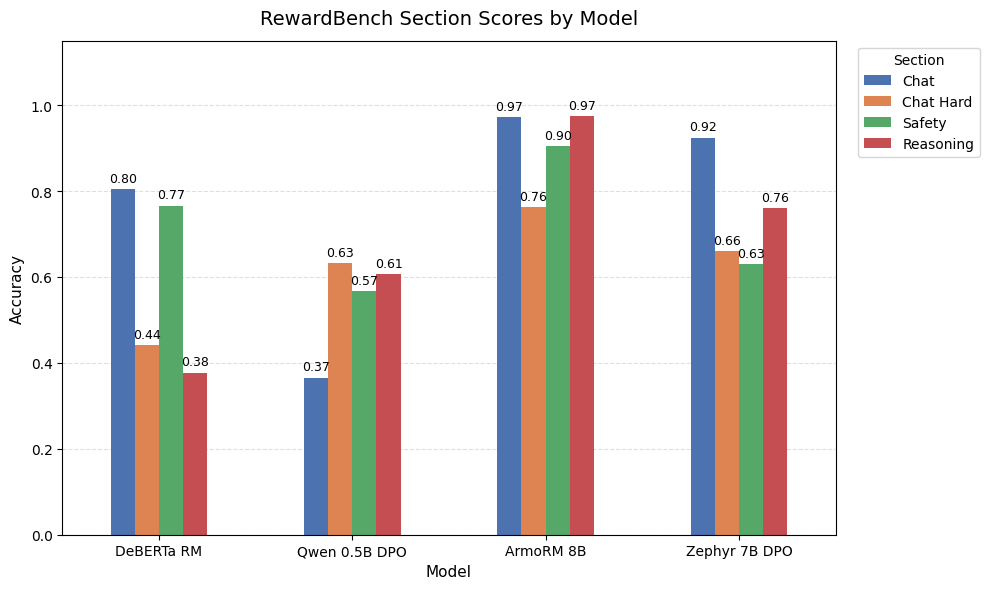

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
results_dir = Path("/content/rewardbench_results")
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Read CSV files
model_df = pd.read_csv(results_dir / "model_comparison.csv")
section_df = pd.read_csv(results_dir / "section_scores.csv")
subset_df = pd.read_csv(results_dir / "subset_scores.csv")

# Short names for cleaner plots (re-added as it was lost in a previous cell execution)
name_map = {
    "OpenAssistant/reward-model-deberta-v3-large-v2": "DeBERTa RM",
    "Qwen/Qwen1.5-0.5B-Chat": "Qwen 0.5B DPO",
    "RLHFlow/ArmoRM-Llama3-8B-v0.1": "ArmoRM 8B",
    "HuggingFaceH4/zephyr-7b-beta": "Zephyr 7B DPO",
}
model_df["short_model"] = model_df["model"].map(name_map)

# Figure 1: RewardBench section scores by model

score_cols = ["chat", "chat_hard", "safety", "reasoning"]

plot_df = model_df.set_index("short_model")[score_cols]
plot_df = plot_df.rename(columns={
    "chat": "Chat",
    "chat_hard": "Chat Hard",
    "safety": "Safety",
    "reasoning": "Reasoning",
})

# Professional color palette (Seaborn 'deep' inspired)
prof_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(kind="bar", ax=ax, color=prof_colors)

ax.set_title("RewardBench Section Scores by Model", fontsize=14, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.15) # Increased to make room for labels
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Section", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig(figures_dir / "section_scores_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

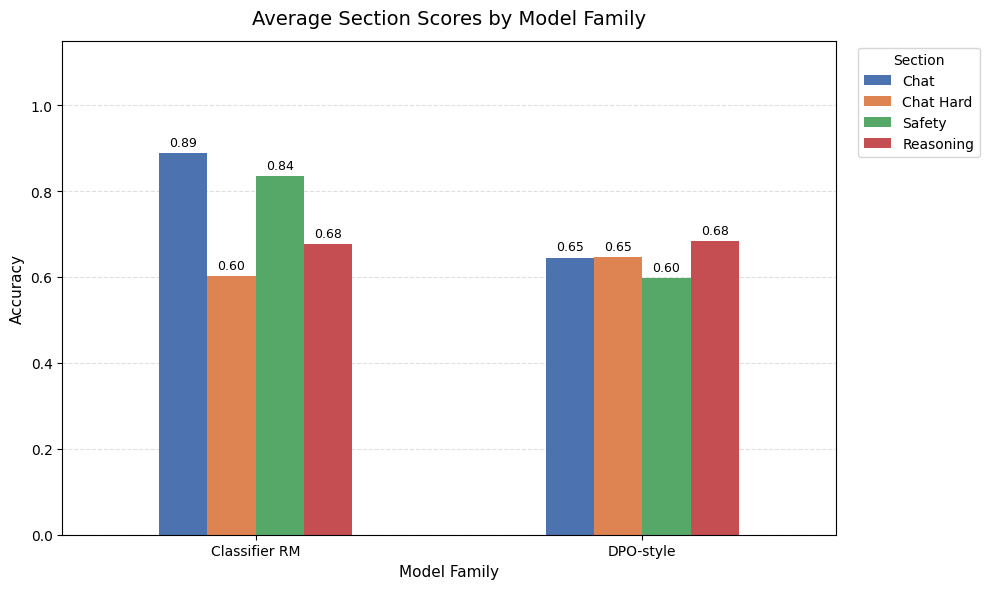

In [35]:
# Figure 2: Average section scores by model family

family_df = model_df.groupby("type")[score_cols].mean()
family_df = family_df.rename(columns={
    "chat": "Chat",
    "chat_hard": "Chat Hard",
    "safety": "Safety",
    "reasoning": "Reasoning",
})

# Professional color palette
prof_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))

family_df.plot(kind="bar", ax=ax, color=prof_colors)

ax.set_title("Average Section Scores by Model Family", fontsize=14, pad=12)
ax.set_xlabel("Model Family", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.15) # Increased to make room for labels
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Section", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig(figures_dir / "model_family_average.png", dpi=300, bbox_inches="tight")
plt.show()

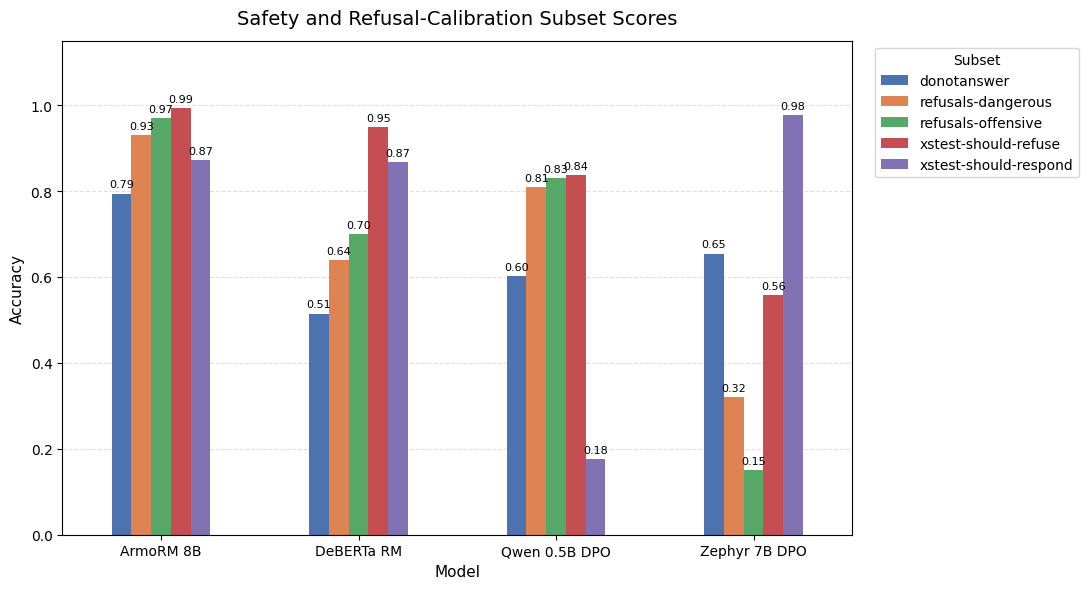

In [37]:
# Figure 3: Safety subset breakdown

name_map = {
    "OpenAssistant/reward-model-deberta-v3-large-v2": "DeBERTa RM",
    "Qwen/Qwen1.5-0.5B-Chat": "Qwen 0.5B DPO",
    "RLHFlow/ArmoRM-Llama3-8B-v0.1": "ArmoRM 8B",
    "HuggingFaceH4/zephyr-7b-beta": "Zephyr 7B DPO",
}
if "short_model" not in subset_df.columns:
    subset_df["short_model"] = subset_df["model"].map(name_map)

safety_subsets = [
    "donotanswer",
    "refusals-dangerous",
    "refusals-offensive",
    "xstest-should-refuse",
    "xstest-should-respond",
]

safety_df = subset_df[subset_df["subset"].isin(safety_subsets)].copy()
pivot = safety_df.pivot(index="short_model", columns="subset", values="score")

# Professional color palette
prof_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

fig, ax = plt.subplots(figsize=(11, 6)) # Adjusted height slightly

pivot.plot(kind="bar", ax=ax, color=prof_colors)

ax.set_title("Safety and Refusal-Calibration Subset Scores", fontsize=14, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.15) # Increased to make room for labels
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Subset", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8) # Slightly smaller font for subsets

plt.xticks(rotation=0, ha="center") # Straighten x-labels
plt.tight_layout()
plt.savefig(figures_dir / "safety_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

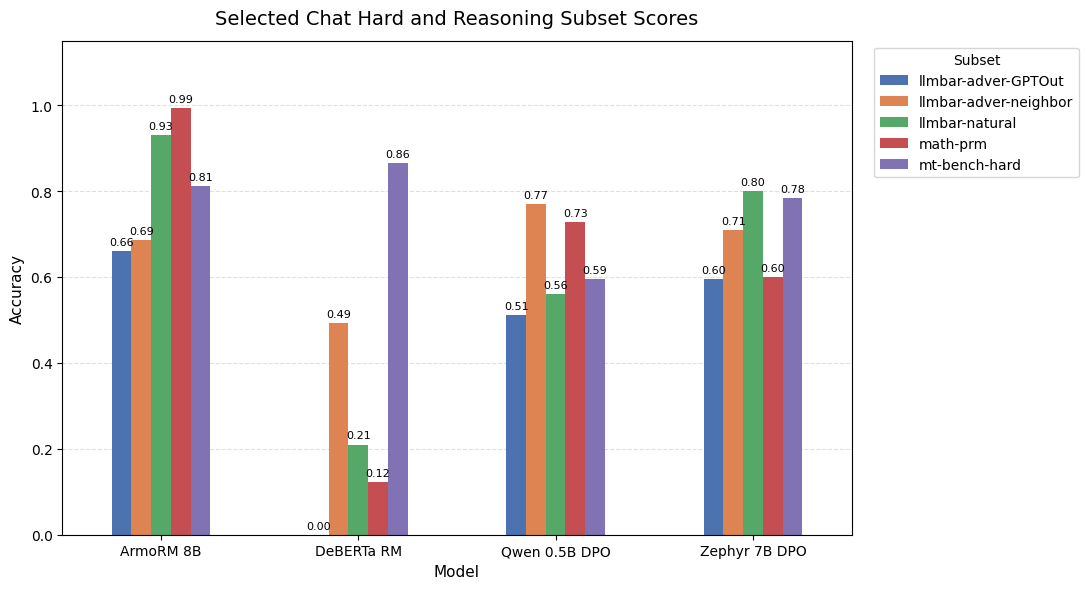

In [38]:
# Figure 4: Hard chat and reasoning subset breakdown

selected_subsets = [
    "llmbar-natural",
    "llmbar-adver-GPTOut",
    "llmbar-adver-neighbor",
    "math-prm",
    "mt-bench-hard",
]

hard_df = subset_df[subset_df["subset"].isin(selected_subsets)].copy()
pivot = hard_df.pivot(index="short_model", columns="subset", values="score")

# Professional color palette
prof_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

fig, ax = plt.subplots(figsize=(11, 6))

pivot.plot(kind="bar", ax=ax, color=prof_colors)

ax.set_title("Selected Chat Hard and Reasoning Subset Scores", fontsize=14, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.15) # Increased to make room for labels
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Subset", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)

plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig(figures_dir / "hard_reasoning_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
# Final check: confirm CSVs and figures exist

from pathlib import Path

results_dir = Path("/content/rewardbench_results")
figures_dir = results_dir / "figures"

print("CSV files:")
!ls -lh /content/rewardbench_results/*.csv

print("\nFigure files:")
!ls -lh /content/rewardbench_results/figures

CSV files:
-rw-r--r-- 1 root root  783 Apr 26 22:40 /content/rewardbench_results/model_comparison.csv
-rw-r--r-- 1 root root  965 Apr 26 22:20 /content/rewardbench_results/section_scores.csv
-rw-r--r-- 1 root root 5.6K Apr 26 22:20 /content/rewardbench_results/subset_scores.csv

Figure files:
total 676K
-rw-r--r-- 1 root root 184K Apr 26 22:51 hard_reasoning_breakdown.png
-rw-r--r-- 1 root root 133K Apr 26 22:50 model_family_average.png
-rw-r--r-- 1 root root 196K Apr 26 22:51 safety_breakdown.png
-rw-r--r-- 1 root root 157K Apr 26 22:47 section_scores_by_model.png


In [43]:
# Package final CSV files and figures into a zip file

from pathlib import Path

results_dir = Path("/content/rewardbench_results")

# Show final files before packaging
print("CSV files:")
!ls -lh /content/rewardbench_results/*.csv

print("\nFigure files:")
!ls -lh /content/rewardbench_results/figures

# Create zip package
!zip -r /content/rewardbench_results_package.zip /content/rewardbench_results

print("\nCreated package:")
!ls -lh /content/rewardbench_results_package.zip

CSV files:
-rw-r--r-- 1 root root  783 Apr 26 22:40 /content/rewardbench_results/model_comparison.csv
-rw-r--r-- 1 root root  965 Apr 26 22:20 /content/rewardbench_results/section_scores.csv
-rw-r--r-- 1 root root 5.6K Apr 26 22:20 /content/rewardbench_results/subset_scores.csv

Figure files:
total 676K
-rw-r--r-- 1 root root 184K Apr 26 22:51 hard_reasoning_breakdown.png
-rw-r--r-- 1 root root 133K Apr 26 22:50 model_family_average.png
-rw-r--r-- 1 root root 196K Apr 26 22:51 safety_breakdown.png
-rw-r--r-- 1 root root 157K Apr 26 22:47 section_scores_by_model.png
updating: content/rewardbench_results/ (stored 0%)
updating: content/rewardbench_results/model_comparison.csv (deflated 46%)
updating: content/rewardbench_results/section_scores.csv (deflated 64%)
updating: content/rewardbench_results/figures/ (stored 0%)
updating: content/rewardbench_results/figures/safety_breakdown.png (deflated 23%)
updating: content/rewardbench_results/figures/section_scores_by_model.png (deflated 25%)
u

In [44]:
# Download final results package

from google.colab import files

files.download("/content/rewardbench_results_package.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>